In [1]:
import tensorflow as tf
import tensorflow_io as tfio

import os
from pathlib import Path
import time
import datetime
import numpy as np
import cv2

from matplotlib import pyplot as plt
from IPython.display import display, clear_output, update_display
from tqdm.notebook import tqdm

from joblib import Memory

2023-04-14 11:54:55.454692: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-04-14 11:54:55.487922: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-04-14 11:54:55.516229: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-04-14 11:54:55.516631: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-14 11:55:01.032668: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

In [2]:
# load normalizer rgb data
LOAD_PATH = Path('../data/mnist_test_seq_rgb.npy')
sequences = np.load(LOAD_PATH)

In [3]:
# Normalizing the images to [-1, 1]
def normalize(sequence):
  return (sequence / 127.5) - 1

# Undo normalizing the images to [0, 255]
@tf.function
def normalized_sequence_to_images(sequence):
  return tf.cast((sequence + 1) * 127.5, tf.uint8)

In [4]:
def plot_sample_sequence(sample_sequence):
    plot_sequence = list(sample_sequence)
    n_frames = len(plot_sequence)
    rows = ((n_frames-1) // 10)+1
    cols = max(n_frames % 10, 10)
    fig = plt.figure(figsize=(20, 4))
    for i, im in enumerate(plot_sequence):
        ax = fig.add_subplot(rows,cols,i+1)
        ax.imshow(im, cmap='gray') 
        ax.axis('off')
    plt.show()
    plt.close()

def sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[0]):
        yield sample_sequence[i, ...]

def plot_sequence(sample_sequence):
    plot_sample_sequence(sequence_generator(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def inverse_sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[-1]):
        yield sample_sequence[..., i]

def plot_inverse_sequence(sample_sequence):
    plot_sample_sequence(inverse_sequence_generator(sample_sequence))

def plot_normalized_inverse_sequence(sample_sequence):
    plot_inverse_sequence(normalized_sequence_to_images(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def plot_sequence_from_tensor(sample_sequence):
    if len(sample_sequence.shape) == 5 and sample_sequence.shape[0] == 1:
        plot_sequence(sample_sequence[0])
    else:
        raise ValueError("The tensor must be of shape (1, frames, height, width, channels)")

def plot_sequence_from_normalized_tensor(sample_sequence):
    plot_sequence_from_tensor(normalized_sequence_to_images(sample_sequence))

In [5]:
print(sequences.shape)
sample_sequence = sequences[0,...]
print(sample_sequence.shape)

(10000, 20, 64, 64, 3)
(20, 64, 64, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

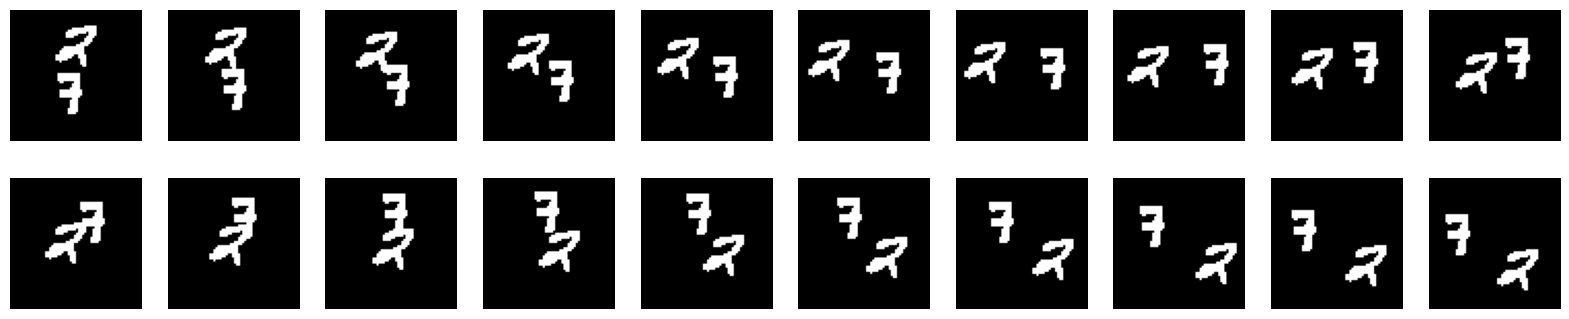

2023-04-14 11:58:32.873576: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-04-14 11:58:32.976901: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1956] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


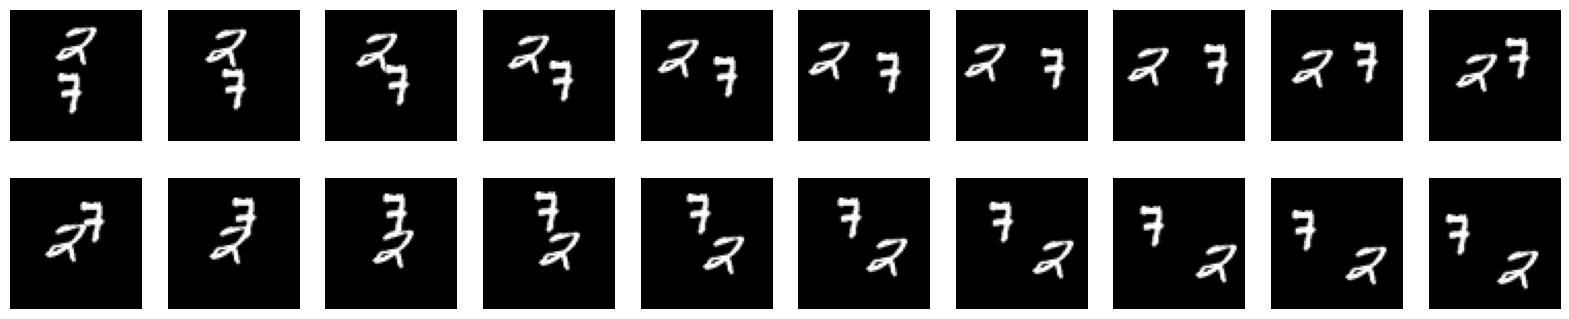

In [6]:
plot_sequence(sample_sequence)
sequences = normalize(sequences) # Normalize sequerences to [-1, 1]
sample_sequence = sequences[0,...]
plot_normalized_sequence(sample_sequence)

In [7]:
SAVE_PATH = Path('../data/mnist_test_seq_rgb_normalized.npy')
np.save(SAVE_PATH, sequences)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

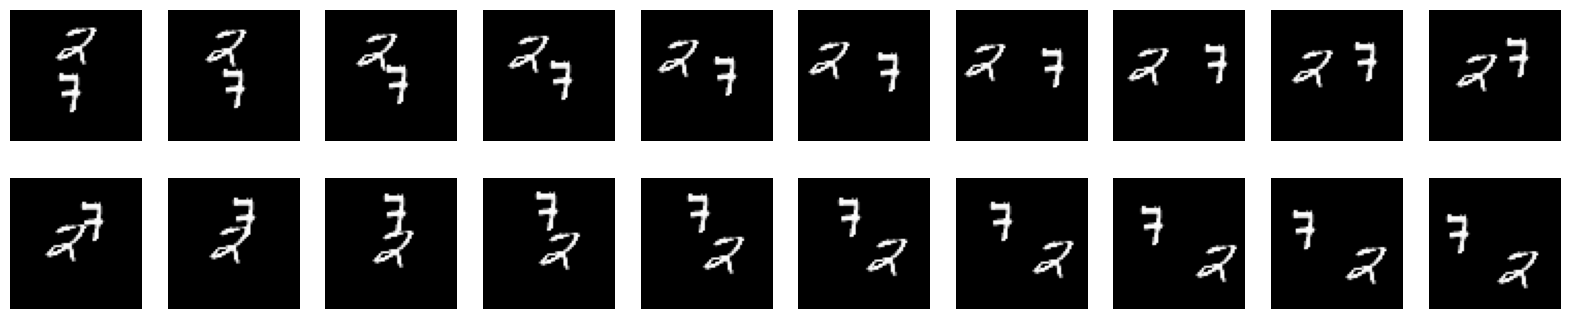

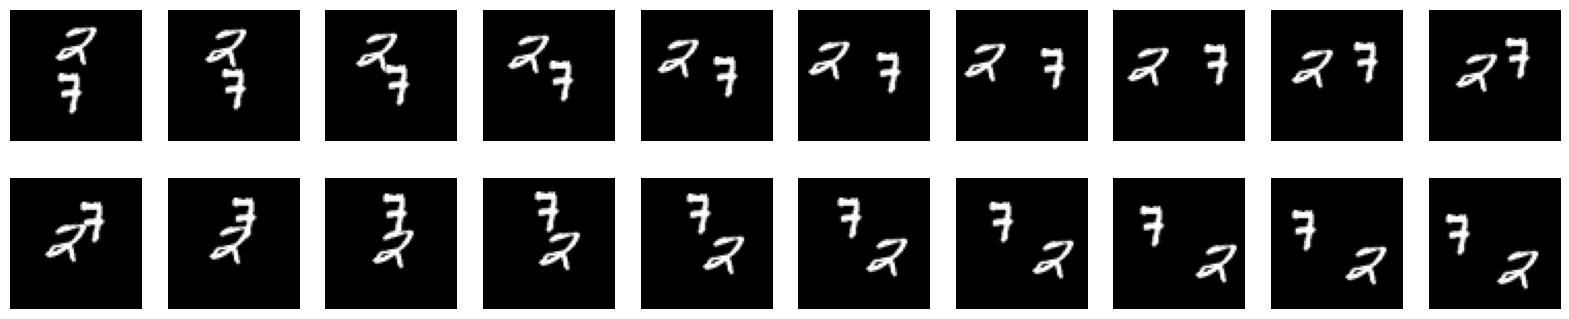

In [8]:
sequences = np.load(SAVE_PATH)
sample_sequence = sequences[0,...]
plot_sequence(sample_sequence)
plot_normalized_sequence(sample_sequence)